# Building Models in PyTorch

This notebook introduces building neural networks in PyTorch. 
We start with simple linear models on dummy data, move to image inputs, 
introduce convolutional layers, and briefly explore example of more advanced architecture (autoencoders).

The goal is to **understand model construction, forward pass, tensor shapes, and feature maps**.

## What are Features?

- In machine learning, a **feature** is an individual measurable property of your data.
- For tabular data, features are usually columns (e.g., height, weight, age).
- For images, features can be:
  - Raw pixel values
  - Higher-level representations extracted by **convolutional layers** (feature maps)
- Neural networks automatically learn **useful features** for the task during training.
- Each layer in a network transforms its input into a new set of features.

> When inspecting tensors after each layer, think of the channel dimension as "different features" extracted by the network.

## Section 1 – Simple Linear Model

We define a linear model manually using PyTorch tensors. This demonstrates 
forward computation and parameter shapes.

In [1]:
import torch

# Example tabular dataset: apartment features
# features: [size_m2, rooms, distance_to_center_km, floor, building_age]

X = torch.tensor([
    [50, 2, 3.5, 4, 10],   # apartment 1
    [70, 3, 5.0, 2, 20],   # apartment 2
    [35, 1, 1.2, 5, 5],    # apartment 3
    [90, 4, 8.0, 1, 30]    # apartment 4
]).float()

# Dummy target: apartment price (in thousands)
y = torch.tensor([
    [420],
    [550],
    [670],
    [213]
]).float()

batch_size, features = X.shape
output_dim = 1

print("Input features:")
print(X)

print("\nTarget prices:")
print(y)

# Initialize weights manually
W = torch.randn(features, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

# Forward pass (linear model)
y_pred = X @ W + b

print("\nModel prediction:")
print(y_pred)

print("\nPrediction shape:", y_pred.shape)

print("\nWeights:", W)

Input features:
tensor([[50.0000,  2.0000,  3.5000,  4.0000, 10.0000],
        [70.0000,  3.0000,  5.0000,  2.0000, 20.0000],
        [35.0000,  1.0000,  1.2000,  5.0000,  5.0000],
        [90.0000,  4.0000,  8.0000,  1.0000, 30.0000]])

Target prices:
tensor([[420.],
        [550.],
        [670.],
        [213.]])

Model prediction:
tensor([[ -7.1970],
        [-11.4259],
        [ -5.0659],
        [-11.4110]], grad_fn=<AddBackward0>)

Prediction shape: torch.Size([4, 1])

Weights: tensor([[-0.6117],
        [ 1.1219],
        [ 1.6004],
        [ 1.8432],
        [ 0.8168]], requires_grad=True)


> A linear layer is simply a weighted sum of input features plus a bias.

```
price =
w1 * size +
w2 * rooms +
w3 * distance +
w4 * floor +
w5 * age +
bias
```

## Section 3 – Linear Model with `nn.Module`

Instead of manual weights, we use `nn.Linear`. This is the standard PyTorch way.

In [2]:
import torch.nn as nn

linear_model = nn.Linear(features, output_dim)
print(linear_model)

# Forward pass on dummy data
y_pred2 = linear_model(X)
print("Output shape:", y_pred2.shape)

print(linear_model.state_dict())

Linear(in_features=5, out_features=1, bias=True)
Output shape: torch.Size([4, 1])
OrderedDict([('weight', tensor([[ 0.2640,  0.4409,  0.3769, -0.0703,  0.3215]])), ('bias', tensor([0.3546]))])


### From Single-Layer to Deep Neural Networks

Single-layer models are simple:

```python
linear_model = nn.Linear(features, output_dim)  # one layer
```

For more complex tasks, we use **Deep Neural Networks** – multiple layers stacked together.

In PyTorch, the standard way is to define a class inheriting from ```nn.Module```:

```python
import torch.nn as nn
import torch.nn.functional as F

class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Define layers
        self.fc1 = nn.Linear(10, 32)  # first hidden layer
        self.fc2 = nn.Linear(32, 16)  # second hidden layer
        self.fc3 = nn.Linear(16, 2)   # output layer

    def forward(self, x):
        # Define how data flows
        x = F.relu(self.fc1(x))       # activation after first layer
        x = F.relu(self.fc2(x))       # activation after second layer
        x = self.fc3(x)               # raw output (logits)
        return x

```



- Each layer learns a different feature representation of the input.
- forward defines the computation graph.
- Using classes allows flexible architectures with many layers.

## Section 4 – Linear Model on Image Data

Images have shape `[batch_size, channels, height, width]`. 
We flatten them to feed into a linear layer.

In [3]:
# Dummy images: batch_size=2, grayscale 32x32
dummy_images = torch.randn(2, 1, 32, 32)

# Flatten for linear layer
dummy_images_flat = dummy_images.view(dummy_images.size(0), -1)
linear_img_model = nn.Linear(32*32, 10)

# Forward pass
out = linear_img_model(dummy_images_flat)
print("Output shape:", out.shape)

Output shape: torch.Size([2, 10])


## Section 5 – Convolutional Neural Network (CNN)

- CNNs process images in their natural shape `[B, C, H, W]`.
- Convolution uses small **kernels (filters)** that slide across the image.
- Each kernel learns to detect a **specific visual pattern** (edges, textures, shapes).
- The same kernel is reused across the whole image (**weight sharing**), which **greatly reduces the number of parameters** compared to fully connected layers.
- Each convolution produces a **feature map** showing where a learned pattern appears in the image.
- Deeper layers combine simple patterns into **more complex visual features**.
- Designing CNNs from scratch requires tracking how both **the number of channels** and **spatial dimensions (H, W)** change after each layer.

---

### Computing the output size of a convolution

To compute the spatial size after a convolution layer, we use:

$$
H_{out} = \left\lfloor \frac{H_{in} + 2P - K}{S} \right\rfloor + 1
$$

Where:

- $H_{in}$ – input height (same formula for width)
- $K$ – kernel size
- $S$ – stride
- $P$ – padding


```
out = floor((W + 2P - K) /S) + 1
```

The same formula applies to the width dimension.


In [4]:
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # input:  [B, 1, 32, 32]
        # Conv2d(in_channels=1, out_channels=8, kernel=3, stride=1)
        # spatial: (32 - 3) / 1 + 1 = 30
        # output: [B, 8, 30, 30]
        self.conv1 = nn.Conv2d(1, 8, 3, 1)
        self.conv2 = nn.Conv2d(8, 16, 3, 1)

        self.fc1 = nn.Linear(16*28*28, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

cnn_model = SimpleCNN()
dummy_out = cnn_model(dummy_images)
print("CNN output shape:", dummy_out)

CNN output shape: tensor([[-0.0861,  0.1171,  0.1823, -0.0228,  0.0198,  0.1212,  0.0491,  0.1603,
          0.0961,  0.0586],
        [-0.0739,  0.1369,  0.1122, -0.0437, -0.0095,  0.1870,  0.0570,  0.1524,
          0.1329,  0.1046]], grad_fn=<AddmmBackward0>)


In [5]:
# from torchinfo import summary
# summary(cnn_model, input_size=(1,1,32,32))

## Section 6 – Autoencoder Concept

- Autoencoders compress input into a **latent space** (encoder) and reconstruct (decoder).
- Useful to show CNNs for **reconstruction/generation**, not only classification.
- Transposed convolutional layers perform up-sampling from a low resolution feature space to a high resolution output.

In [6]:
class SimpleAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.enc1 = nn.Conv2d(1, 8, 3, 2, 1)  
        # H_out = floor((H + 2p - k)/s) + 1 = floor((H + 2*1 - 3)/2) + 1 ≈ H/2

        self.enc2 = nn.Conv2d(8, 4, 3, 2, 1)

        # Decoder
        self.dec1 = nn.ConvTranspose2d(4, 8, 3, 2, 1, 1)  
        # H_out = (H-1)*s - 2p + k + op = (H-1)*2 - 2 + 3 + 1 = 2H

        self.dec2 = nn.ConvTranspose2d(8, 1, 3, 2, 1, 1)

    def forward(self, x):
        x = F.relu(self.enc1(x))
        x = F.relu(self.enc2(x))
        x = F.relu(self.dec1(x))
        x = torch.sigmoid(self.dec2(x))
        return x


### Why Autoencoders?

Autoencoders are an example of **representation learning**.

Instead of predicting a label, the network learns a **compressed representation of the input data** (called a *latent space*).

This encoder–decoder pattern appears in many important machine learning systems.

Examples:

**Image compression**  
The encoder learns a compact representation of an image that can later be reconstructed.

**Denoising**  
The network learns to reconstruct a clean image from a noisy one.

**Super-resolution**  
A model reconstructs a higher-resolution image from a low-resolution input.

**Image generation**  
Many generative models use a latent space that is decoded into images (e.g., VAEs, diffusion models).

**Feature extraction**  
The latent representation can be used as input for other tasks such as classification or clustering.

In this exercise we will **not train the model**, but we will build the **architecture** and inspect how data flows through an encoder–decoder network.

# Final Exercise – Build & Inspect Your Own Model

## Basic Level – MNIST Digit Classification Model

Build a neural network for **image classification using MNIST**, that predicts the **digit class (0–9)**.
The goal of this exercise is **building and inspecting a neural network**, not training it. 

Input:
MNIST image  
shape: `[batch_size, 1, 28, 28]`

Output:
digit prediction (0–9)  
shape: `[batch_size, 10]`

Compare **2 architectures**:
- linear model
- CNN

Steps:

#### 0. Load the data

In [7]:
# actual images (in batches)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_subset = Subset(train_dataset, range(100))
train_loader = DataLoader(train_subset, batch_size=30, shuffle=True)
data_iter = iter(train_loader)

# dummy image batch (from random numbers)
dummy_image = torch.randn(1, 28, 28)

#### 1. Define your model architecture.

In [8]:
import torch.nn.functional as F
import torch.nn as nn

# linear model for image (flattened)

lin_model = nn.Linear(28*28, 10)

# CNN model for image classification

class CNNmodel(nn.Module):
    def __init__(self, output_dim=10):
        super().__init__()

        # input:  [B, 1, 28, 28]
        # spatial: (28 - 3) / 1 + 1 = 26
        # output: [B, 8, 26, 26]
        self.conv1 = nn.Conv2d(1, 8, 3, 1)
        # input:  [B, 1, 26, 26]
        # spatial: (26 - 3) / 1 + 1 = 24
        # output: [B, 8, 24, 24]
        self.conv2 = nn.Conv2d(8, 16, 3, 1)

        self.fc1 = nn.Linear(16*24*24, 64)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

cnn_model = CNNmodel()

2. Count number of parameters of your model.

In [9]:
# Comparison of numbers of parameters for both models

# linear model
print("Linear model parameters:")
for name, param in lin_model.named_parameters():
    print(f"\t{name}: \t{param.numel()} parameters")

# CNN model
print("\nCNN model parameters:")
for name, param in cnn_model.named_parameters():
    print(f"\t{name}: \t{param.numel()} parameters")

Linear model parameters:
	weight: 	7840 parameters
	bias: 	10 parameters

CNN model parameters:
	conv1.weight: 	72 parameters
	conv1.bias: 	8 parameters
	conv2.weight: 	1152 parameters
	conv2.bias: 	16 parameters
	fc1.weight: 	589824 parameters
	fc1.bias: 	64 parameters
	fc2.weight: 	640 parameters
	fc2.bias: 	10 parameters


3. Run a **forward pass** on:
    - dummy image (1, 28, 28)
    - example batch from MNIST (from Dataloader)
    - example element of Dataset MNIST
    - all MNIST data (iterate over the dataset using a `DataLoader`) and calculate accuracy

Example:

```python
correct = 0
total = 0

for images, labels in train_loader:

    outputs = model(images)
    preds = outputs.argmax(dim=1)

    correct += (preds == labels).sum().item()
    total += labels.size(0)

accuracy = correct / total
print("Accuracy:", accuracy)
```

In [10]:
# dummy image batch (from random numbers)
Y_a_lin = lin_model(dummy_image.flatten(start_dim=1))
Y_a_cnn = cnn_model.forward(dummy_image.unsqueeze(1))

# example batch from MNIST
X_example, y_example = next(iter(train_loader))
Y_example_lin = lin_model(X_example.view(X_example.size(0), -1))
Y_example_cnn = cnn_model(X_example)

# example element of dataset mnist
X_single, y_single = train_dataset[0]
Y_single_lin = lin_model(X_single.view(1, -1))
Y_single_cnn = cnn_model(X_single.unsqueeze(0))

#  all MNIST data
correct_lin = 0
total_lin = 0

correct_cnn = 0
total_cnn = 0

for images, labels in train_loader:

    outputs_lin = lin_model(images.flatten(start_dim=1))
    preds_lin = outputs_lin.argmax(dim=1)

    outputs_cnn = cnn_model(images)
    preds_cnn = outputs_cnn.argmax(dim=1)

    correct_lin += (preds_lin == labels).sum().item()
    total_lin += labels.size(0)

    correct_cnn += (preds_cnn == labels).sum().item()
    total_cnn += labels.size(0)

accuracy_lin = correct_lin / total_lin if total_lin > 0 else 0
accuracy_cnn = correct_cnn / total_cnn if total_cnn > 0 else 0

# Comparison of performance for both models on the same input

print("\t\t\tLinear Model:\t\tyCNN Model:")
print(f"Dummy image:\t\t{Y_a_lin.shape}\t{Y_a_cnn.shape}")
print(f"Example batch:\t\t{Y_example_lin.shape}\t{Y_example_cnn.shape}")
print(f"Single image:\t\t{Y_single_lin.shape}\t{Y_single_cnn.shape}")
print(f"All MNIST data:\t\t{accuracy_lin:.2f}\t\t\t{accuracy_cnn:.2f}")

			Linear Model:		yCNN Model:
Dummy image:		torch.Size([1, 10])	torch.Size([1, 10])
Example batch:		torch.Size([30, 10])	torch.Size([30, 10])
Single image:		torch.Size([1, 10])	torch.Size([1, 10])
All MNIST data:		0.10			0.10


4. Inspect the model, print:
    - input tensor shape
    - output tensor shape
    - number of parameters

Example:

```python
sum(p.numel() for p in model.parameters())
```


In [11]:
print("\t\t\tLinear Model:\t\tCNN Model:")
# Case 1: use on one image
print("\nCase 1: single image input")
print("Input:\t\t\t", Y_single_lin.shape, "\t", Y_single_cnn.shape)
print("Output:\t\t\t", Y_single_lin.shape, "\t", Y_single_cnn.shape)

# Case 2: use on batch of images
print("\nCase 2: batch of images input")
print("Input:\t\t\t", Y_example_lin.shape, "\t", Y_example_cnn.shape)
print("Output:\t\t\t", Y_example_lin.shape, "\t", Y_example_cnn.shape)

print("\nnr of parameters:\t", sum(p.numel() for p in lin_model.parameters()), "\t\t\t", sum(p.numel() for p in cnn_model.parameters()))


			Linear Model:		CNN Model:

Case 1: single image input
Input:			 torch.Size([1, 10]) 	 torch.Size([1, 10])
Output:			 torch.Size([1, 10]) 	 torch.Size([1, 10])

Case 2: batch of images input
Input:			 torch.Size([30, 10]) 	 torch.Size([30, 10])
Output:			 torch.Size([30, 10]) 	 torch.Size([30, 10])

nr of parameters:	 7850 			 591786


5. Change the goal of the Model and run a **forward pass** as in previous step.

Imagine that instead of predicting digits (0–9) we would like to directly predict whether the digit is **even or odd**.

New output:

```
[batch_size, 2]
```

You will need to convert MNIST labels:

```python
labels_even_odd = labels % 2
```

In [12]:
# goal - detection of result x % 4
# changing the model output dim to 4
modulo4_model = CNNmodel(output_dim=4)
labels_mod4 = y_example % 4
outputs_mod4 = modulo4_model.forward(X_example)
print("Output shape for modulo 4 model:", outputs_mod4.shape)

Output shape for modulo 4 model: torch.Size([30, 4])


6. Send your model to device (gpu or cpu).

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

device_cnn_model = cnn_model.to(device)

Using device: cuda


---

## Deep Level – Beyond Classification

Neural networks are **not limited** to classification. 

Instead of predicting a label, build a network that **reconstructs the input image**.

Architecture idea: Autoencoder

```
image → encoder → latent space → decoder → reconstructed image
```

Input:

```
[batch_size, 1, 28, 28]
```

Output:

```
[batch_size, 1, 28, 28]
```

Steps:

#### 1. Build an **autoencoder**-like architecture that compresses the image and then reconstruct it.



In [14]:
import torch.nn as nn
import torch.nn.functional as F
import torch

class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        # H_out = floor((H + 2p - k)/s) + 1 = floor((H + 2*1 - 3)/2) + 1 ≈ H/2

        # input:  [B, 1, 28, 28]
        # H_out = floor((28 + 2*1 - 3)/2) + 1 = floor(28/2) = 14
        # output: [B, 8, 14, 14]
        self.enc1 = nn.Conv2d(1, 8, 3, 2, 1)  
        
        # input:  [B, 1, 14, 14]
        # H_out = floor((14 + 2*1 - 3)/2) + 1 = floor(14/2) = 7
        # output: [B, 4, 7, 7]
        self.enc2 = nn.Conv2d(8, 4, 3, 2, 1)

        # input:  [B, 1, 7, 7]
        # H_out = floor((7 + 2*1 - 3)/2) + 1 = floor(7/2) = 4
        # output: [B, 4, 3, 3]
        self.enc3 = nn.Conv2d(4, 4, 3, 2, 1)

        # Decoder
        # H_out = (H-1)*s - 2p + k + op = (H-1)*2 - 2 + 3 + 1 = 2H

        # input [B, 4, 3, 3]
        # H_out = (3-1)*2 - 2 + 2 + 1 = 7
        # output [B, 8, 7, 7]
        self.dec1 = nn.ConvTranspose2d(4, 8, 2, 2, 1, 1)  

        # input [B, 4, 7, 7]
        # H_out = (7-1)*2 - 2 + 3 + 1 = 14
        # output [B, 8, 14, 14]
        self.dec2 = nn.ConvTranspose2d(8, 4, 3, 2, 1, 1)  
        
        # input [B, 4, 14, 14]
        # H_out = (14-1)*2 - 2 + 3 + 1 = 28
        # output [B, 8, 28, 28]
        self.dec3 = nn.ConvTranspose2d(4, 1, 3, 2, 1, 1)

    def forward(self, x):
        x = F.relu(self.enc1(x))
        x = F.relu(self.enc2(x))
        x = F.relu(self.enc3(x))
        latent_representation = x
        x = torch.sigmoid(self.dec1(x))
        x = torch.sigmoid(self.dec2(x))
        x = torch.sigmoid(self.dec3(x))
        return x, latent_representation
    
autoencoder_model = ConvAutoencoder()

#### 2. Run a forward pass.

In [15]:
Y_auto, _ = autoencoder_model(X_example)
print("Autoencoder input shape:\t", X_example.shape)
print("Autoencoder output shape:\t", Y_auto.shape)

Autoencoder input shape:	 torch.Size([30, 1, 28, 28])
Autoencoder output shape:	 torch.Size([30, 1, 28, 28])


#### 3. Inspect:
   - latent representation shape
   - reconstructed image shape
   - reconstructed image itself (`plt.imshow(output[0, 0].detach().cpu())`)
   - parameter count

Latent representation shape: torch.Size([30, 4, 4, 4])
Reconstructed image shape: torch.Size([30, 1, 28, 28])
Parameter count: 985


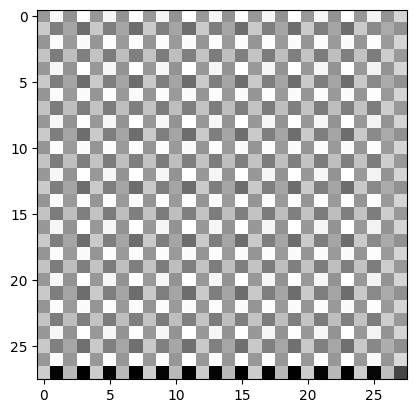

In [16]:
_, latent_repr = autoencoder_model(X_example)
print("Latent representation shape:", latent_repr.shape)
print("Reconstructed image shape:", Y_auto.shape)
print("Parameter count:", sum(p.numel() for p in autoencoder_model.parameters()))

from matplotlib import pyplot as plt
img = Y_auto[0] 
img = img.squeeze() 
img_np = img.detach().cpu().numpy()
plt.imshow(img_np, cmap='gray')
plt.show()

